In [1]:
import os
import sys
import glob
import rasterio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../ProcessEvents/')
from config import CATCHMENT_LOOKUP_DICT, OUT_DIR # MOLLY_DIR_FF, RAINFALL_CSV_DIR, ENSEMBLE_MEMBERS, , CATCHMENTS

In [2]:
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())

catchments_with_flood_output = []
for catchment_num in all_catchments:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    flood_fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/Ens01_{catchment_num}/10cm/flooded_area_5km_total_Ens01_{catchment_num}_10cm.nc"
        
    if os.path.isfile(flood_fp) and os.path.isfile(fp):
        catchments_with_flood_output.append(catchment_num)

In [3]:
rainfall_events_all = []
for catchment_num in catchments_with_flood_output:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    rainfall_events = pd.read_pickle(fp)
    rainfall_events_complete = rainfall_events[rainfall_events['mismatch']!=True].copy()
    rainfall_events['catchment_num'] = catchment_num
    # print(f"Catchment {catchment_num} has {len(rainfall_events)}, of which {len(rainfall_events) - len(rainfall_events_complete)} are mismatched")
    rainfall_events_all.append(rainfall_events) 
rainfall_events_all_df = pd.concat(rainfall_events_all, ignore_index=True)   
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()

0.0 1.0


/scratch/hydro4/users/kv25483/FutureFlood/Scripts/AnalyseResults/ipykernel_1957825/345809829.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


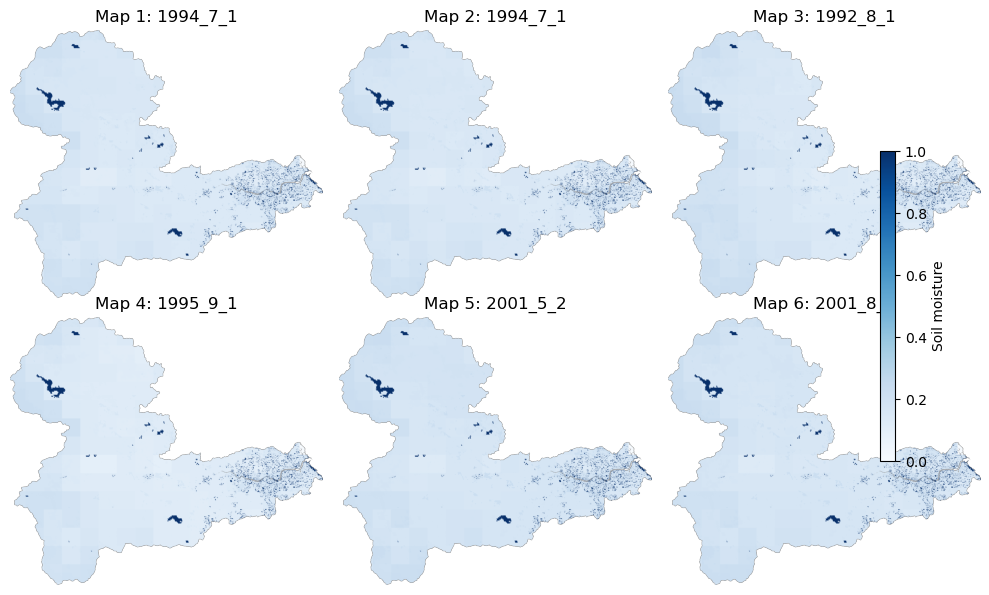

In [32]:
files = glob.glob("/scratch/hydro5/users/la17355/FUTURE-FLOOD/UKCP_soil_moisture/volumetric_30m/Ens_01/tif/23/*")

vmin, vmax = np.inf, -np.inf

for fp in files:
    with rasterio.open(fp) as src:
        data = src.read(1)
        nodata = src.nodata

    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)

    vmin = min(vmin, np.nanmin(data))
    vmax = max(vmax, np.nanmax(data))

print(vmin, vmax)


fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(10, 6))
axs = axs.flatten()

im = None  # will store last image for colorbar

for i, fp in enumerate(files[:6]):  # limit to 6 plots
    with rasterio.open(fp) as src:
        data = src.read(1)
        nodata = src.nodata

    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)

    im = axs[i].imshow(data, cmap='Blues', vmin=vmin, vmax=vmax)
    axs[i].set_title(f"Map {i+1}: {fp[101:109]}")
    axs[i].axis('off')

# 🔑 one shared colorbar
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label("Soil moisture")

plt.tight_layout()
plt.show()

In [26]:
stats = []

for fp in files:
    with rasterio.open(fp) as src:
        data = src.read(1)
        nodata = src.nodata

    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)

    stats.append({ 'file': fp.split('/')[-1], 'mean': np.nanmean(data), 'std': np.nanstd(data), 'min': np.nanmin(data),
                  'max': np.nanmax(data)})

df_stats = pd.DataFrame(stats)
print(df_stats)

                                    file      mean       std   min  max
0   soil_5_3_2046_8_4_Ens_01_vol_30m.tif  0.219081  0.155550  0.09  1.0
1   soil_5_2_2044_7_7_Ens_01_vol_30m.tif  0.187754  0.163246  0.05  1.0
2   soil_5_1_2026_7_6_Ens_01_vol_30m.tif  0.203514  0.158799  0.07  1.0
3   soil_5_4_2047_8_7_Ens_01_vol_30m.tif  0.189942  0.164919  0.03  1.0
4  soil_5_5_2056_8_22_Ens_01_vol_30m.tif  0.175245  0.164758  0.04  1.0
5  soil_5_6_2066_7_29_Ens_01_vol_30m.tif  0.213884  0.158475  0.04  1.0
6  soil_5_7_2078_7_26_Ens_01_vol_30m.tif  0.189619  0.162588  0.04  1.0
7  soil_5_8_2080_7_14_Ens_01_vol_30m.tif  0.223855  0.152612  0.10  1.0


In [4]:
import iris
ens='01'
year=2020
sm_dir  = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens}/'
sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]

sm_yr = iris.load(sm_file)[0]
# Convert masked → NaN
sm_arr = sm_yr.data.filled(np.nan) if np.ma.is_masked(sm_yr.data) else sm_yr.data

# import geopandas as gpd
# regions_shp = "/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/plots/most_exposed_events_visualisation/by_region/ukcp18-uk-land-region-hires.shp"
# regions_df = gpd.read_file(regions_shp)
# regions_df
catchment_num = '1'
    
# Get data for the catchment

from config import CATCHMENTS  
catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
CATCHMENT_POLY


In [ ]:
import iris
import iris.coord_categorisation
import numpy as np

# Catchment bounding box
xmin, ymin, xmax, ymax = CATCHMENT_POLY.bounds

# Get spatial coordinate names
x_coord = 'projection_x_coordinate'
y_coord = 'projection_y_coordinate'

# Create constraint
bbox_constraint = iris.Constraint(
    coord_values={
        x_coord: lambda cell: xmin <= cell <= xmax,
        y_coord: lambda cell: ymin <= cell <= ymax
    }
)

# Extract cropped cube
sm_crop = sm_yr.extract(bbox_constraint)

print(sm_crop.shape)

(360, 16, 18)
Soil moisture shape: (360, 16, 18)
Catchment CRS: EPSG:27700
Cube CRS: TransverseMercator(latitude_of_projection_origin=49.0, longitude_of_central_meridian=-2.0, false_easting=400000.0, false_northing=-100000.0, scale_factor_at_central_meridian=0.9996012717, ellipsoid=GeogCS(semi_major_axis=6377563.396, semi_minor_axis=6356256.909))
Masked soil moisture shape: (360, 16, 18)


/scratch/hydro4/users/kv25483/FutureFlood/Scripts/AnalyseResults/ipykernel_1957825/1267982835.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


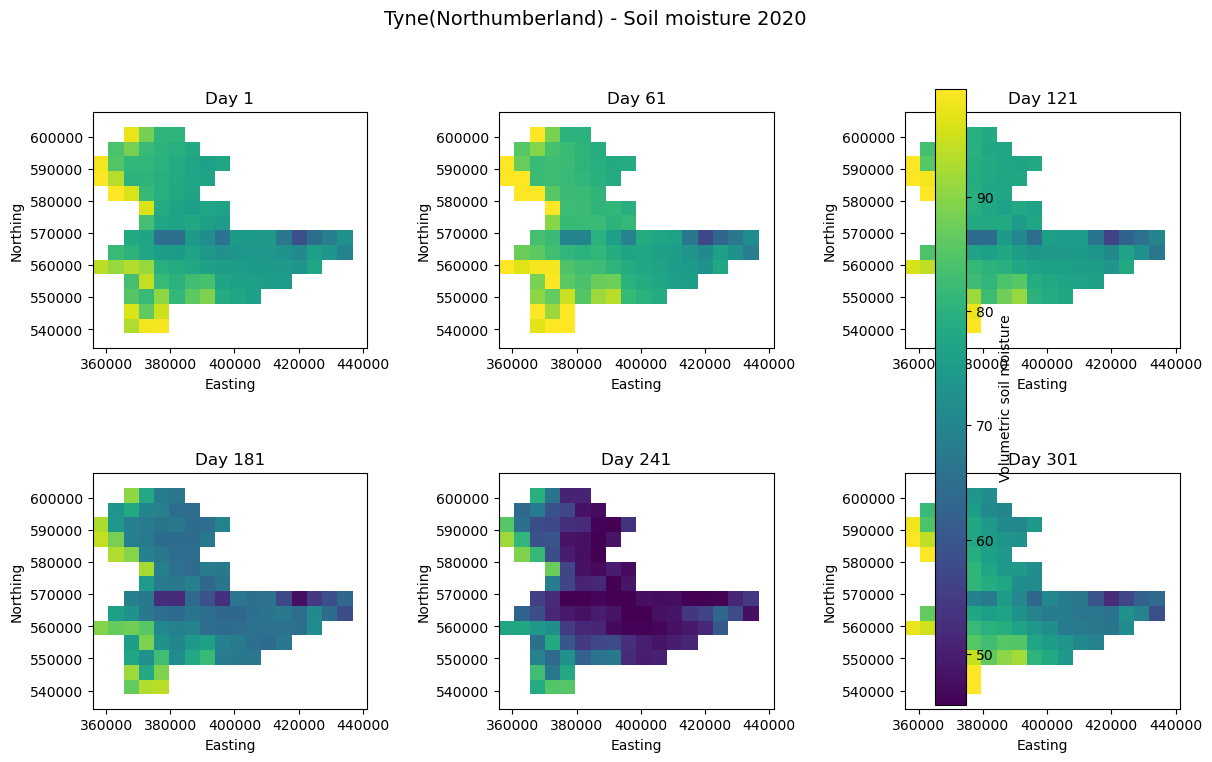

In [20]:
import iris
import glob
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# -----------------------------
# Load soil moisture cube
# -----------------------------
ens = '01'
year = 2020

sm_dir = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens}/'

sm_file = glob.glob(
    f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc"
)[0]

sm_yr = iris.load(sm_file)[0]

# Get spatial coordinate names
x_coord = 'projection_x_coordinate'
y_coord = 'projection_y_coordinate'

# Create constraint
bbox_constraint = iris.Constraint(
    coord_values={
        x_coord: lambda cell: xmin <= cell <= xmax,
        y_coord: lambda cell: ymin <= cell <= ymax
    }
)

# Extract cropped cube
sm_crop = sm_yr.extract(bbox_constraint)

print(sm_crop.shape)


# Convert masked array -> NaN
sm_arr = (
    sm_crop.data.filled(np.nan)
    if np.ma.is_masked(sm_yr.data)
    else sm_crop.data
)

print("Soil moisture shape:", sm_arr.shape)

# -----------------------------
# Get catchment polygon
# -----------------------------
catchment_num = '23'

from config import CATCHMENTS, CATCHMENT_LOOKUP_DICT

catchment_name = CATCHMENT_LOOKUP_DICT[str(catchment_num)]

boundary_gdf = CATCHMENTS[
    CATCHMENTS['HA_NUM'] == str(catchment_num)
]

CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]


# -----------------------------
# Get grid coordinates
# -----------------------------
# Check coordinate names if these fail
x = sm_crop.coord('projection_x_coordinate').points
y = sm_crop.coord('projection_y_coordinate').points

xx, yy = np.meshgrid(x, y)


# -----------------------------
# Create spatial mask
# -----------------------------
# Ensure polygon and grid use same CRS
print("Catchment CRS:", boundary_gdf.crs)
print("Cube CRS:", sm_crop.coord_system())


points = gpd.GeoDataFrame(
    geometry=[
        Point(xi, yi)
        for xi, yi in zip(xx.ravel(), yy.ravel())
    ],
    crs=boundary_gdf.crs
)

inside = points.within(CATCHMENT_POLY)

catchment_mask = inside.values.reshape(xx.shape)


# -----------------------------
# Apply mask to all days
# -----------------------------
# sm_arr = (time, y, x)
sm_catchment = np.where(
    catchment_mask[None, :, :],
    sm_arr,
    np.nan
)

print("Masked soil moisture shape:", sm_catchment.shape)


# -----------------------------
# Plot every 60th day
# -----------------------------
days = range(0, sm_catchment.shape[0], 60)

fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 8)
)

axes = axes.flatten()

xmin, ymin, xmax, ymax = CATCHMENT_POLY.bounds
extent = [
    xmin,
    xmax,
    ymin,
    ymax]

# consistent colour scale
vmin = np.nanpercentile(sm_catchment, 2)
vmax = np.nanpercentile(sm_catchment, 98)

for ax, day in zip(axes, days):

    im = ax.imshow(
        sm_catchment[day],
        extent=extent,
        origin='lower',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"Day {day+1}")
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")

fig.colorbar(
    im,
    ax=axes,
    label="Volumetric soil moisture"
)

plt.suptitle(
    f"{catchment_name} - Soil moisture 2020",
    fontsize=14
)

plt.tight_layout()
plt.show()